# Get Putative Biologically Active Leads from GNINA Results

**Project:** Acarbose Alternative Drug Discovery  
**Notebook Purpose:** Visualize distribution of CNN-VS scores across first-pass docking results between COCONUT candidates and proteins 2QMJ, 3BAJ, and 5NN8. Get biologically active leads for all protein targets.

**Key Questions**
- What is the distribution of CNN-VS scores for acarbose-like ligands from COCONUT?
- Are there ligands that pass the CNN-VS >= 6.30 threshold?
- How does the original docking compare to reseeded runs?

## 1. Setup & Imports

In [11]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from aadd import load_and_process_gnina

## 2. Helper Functions

In [12]:
def save_actives(
    df,
    out_ids_path,
    threshold=6.30
) -> pd.DataFrame:
    """
    Subset df to cnn_vs >= threshold and write identifiers to txt.

    Returns
    -------
    active_df : pd.DataFrame
    """
    active_df = df[df["cnn_vs"] >= threshold]

    with open(out_ids_path, "w") as f:
        for mol_id in active_df["identifier"]:
            f.write(f"{mol_id}\n")

    return active_df

def plot_cnn_vs_grid(
    dfs,
    titles=None,
    threshold=6.30,
    bins="auto",
    max_per_row=3,
    figsize_per_plot=(5, 4)
):
    """
    Plot CNN_VS histograms in an adaptive grid layout (max 3 per row).

    Parameters
    ----------
    dfs : list[pd.DataFrame]
        Preprocessed GNINA result dfs
    titles : list[str] or None
        Optional titles per plot
    threshold : float
        CNN_VS cutoff line
    bins : int | str
        Histogram binning
    max_per_row : int
        Maximum plots per row
    figsize_per_plot : tuple
        Size per subplot
    """
    n = len(dfs)
    ncols = min(max_per_row, n)
    nrows = math.ceil(n / ncols)

    figsize = (
        figsize_per_plot[0] * ncols,
        figsize_per_plot[1] * nrows
    )

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)

    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    if titles is None:
        titles = [f"Dataset {i+1}" for i in range(n)]

    for ax, df, title in zip(axes, dfs, titles):
        ax.hist(df["cnn_vs"], bins=bins)
        ax.axvline(threshold)
        ax.set_title(title)
        ax.set_xlabel("CNN-VS")

    # turn off unused axes
    for ax in axes[len(dfs):]:
        ax.axis("off")

    axes[0].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 3. Process & Plot

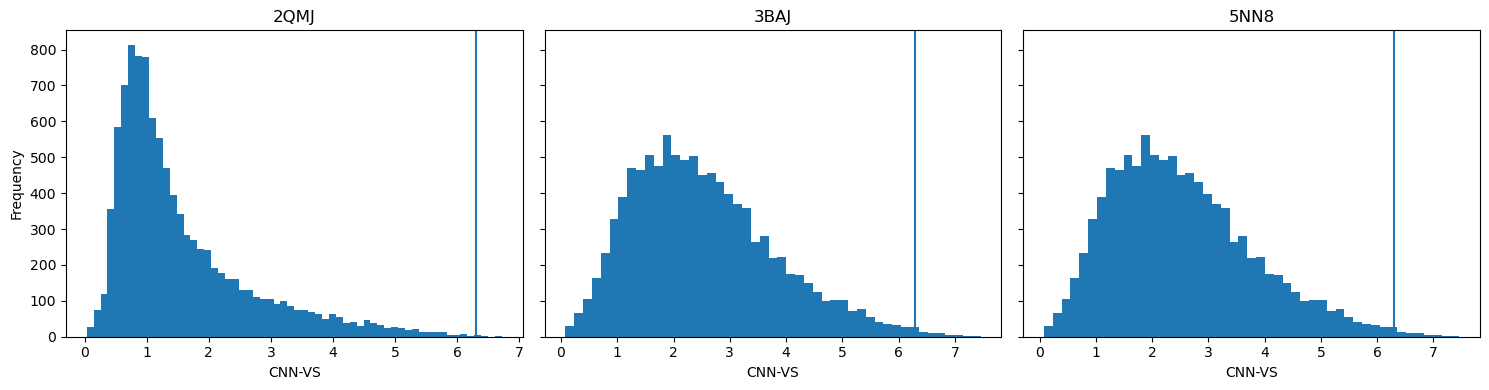

In [13]:
parquets = [
    "../2qmj_vs.parquet",
    "../3baj_vs.parquet",
    "../3baj_vs.parquet"
]

dfs = [load_and_process_gnina(p) for p in parquets]

for df, name in zip(dfs, ["2qmj", "3baj", "5nn8"]):
    save_actives(df, f"{name}_active_ids.txt", threshold=6.30)

plot_cnn_vs_grid(
    dfs,
    titles=["2QMJ", "3BAJ", "5NN8"],
    threshold=6.30
)
